# Group-Level comparison of Epoch-Based Decoding Performance

This script aggregates  decoding curves of P300 workflow variants.




In [14]:
import os
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [15]:
def load_decoding_results(npz_path):
    with np.load(npz_path) as data:
        epoch_bins_loaded = data['epoch_bins']
        mean_acc = data['mean_accuracies']
        se_acc = data['se_accuracies']
    return epoch_bins_loaded, mean_acc, se_acc


In [16]:
manuscript_dir = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript'
m_ica_dir = join(manuscript_dir, 'data', 'decoding', 'ica')
m_noica_dir = join(manuscript_dir, 'data', 'decoding','noica')
fig_dir = join(manuscript_dir, 'figures')

epoch_bins = np.linspace(5, 80, 16, dtype=int)
task = 'covert'


# Full paths
data1_path = os.path.join(m_ica_dir, f"{task}_lda_p300_decC_64_ica_noreject.npz")
data2_path = os.path.join(m_noica_dir, f"{task}_lda_p300_decC_64_noica_noreject.npz" )
data3_path = os.path.join(m_ica_dir, f"{task}_lda_alphaCSP_decC_64_ica.npz")
data4_path = os.path.join(m_noica_dir, f"{task}_lda_alphaCSP_decC_64_noica.npz" )
data5_path = os.path.join(m_ica_dir, f"{task}_lda_cvep_decC_64_ica.npz" )
data6_path = os.path.join(m_noica_dir, f"{task}_lda_cvep_decC_64_noica.npz" )
# data7_path = os.path.join(m_ica_dir, f"{task}_lda_alphaSUBSET_decC_64_nativespace.npz")
# data8_path = os.path.join(m_noica_dir, f"{task}_lda_alphaSUBSET_decC_64_noica.npz" )

# --...---...---...---...---...---...---...---...---...---...---...---...---...-
epoch_bins1, mean_acc1, se_acc1 = load_decoding_results(data1_path)
epoch_bins2, mean_acc2, se_acc2 = load_decoding_results(data2_path)
epoch_bins3, mean_acc3, se_acc3 = load_decoding_results(data3_path)
epoch_bins4, mean_acc4, se_acc4 = load_decoding_results(data4_path)
epoch_bins5, mean_acc5, se_acc5 = load_decoding_results(data5_path)
epoch_bins6, mean_acc6, se_acc6 = load_decoding_results(data6_path)
# epoch_bins7, mean_acc7, se_acc7 = load_decoding_results(data7_path)
# epoch_bins8, mean_acc8, se_acc8 = load_decoding_results(data8_path)
# --...---...---...---...---...---...---...---...---...---...---...---...---...-
data = {
    'P300 w/ ICA': {
        'mean': mean_acc1,
        'se': se_acc1,
        'color': 'blue',
        'marker': 'o',
        'linestyle': '-'
    },
    'P300 w/o ICA': {
        'mean': mean_acc2,
        'se': se_acc2,
        'color': 'tab:blue',
        'marker': 'o',
        'linestyle': '-'
    },
    'alpha w/ ICA': {
        'mean': mean_acc3,
        'se': se_acc3,
        'color': 'orange',
        'marker': 'o',
        'linestyle': '-'
    },
    'alpha w/o ICA': {
        'mean': mean_acc4,
        'se': se_acc4,
        'color': 'tab:orange',
        'marker': 'o',
        'linestyle': '-'
        },
    #'Alpha subset w/ ICA': {
    #    'mean': mean_acc7,
    #    'se': se_acc3,
    #    'color': 'tab:orange',
    #    'marker': 'x',
    #    'linestyle': '-'
    #},
    #'Alpha subset wo/ ICA': {
    #    'mean': mean_acc8,
    #    'se': se_acc4,
    #    'color': 'tab:orange',
    #    'marker': 'x',
    #    'linestyle': '--'

    #},
    'cVEP w/ ICA': {
        'mean': mean_acc5,
        'se': se_acc5,
        'color': 'green',
        'marker': 'o',
        'linestyle': '-'
    },
    'cVEP w/o ICA': {
        'mean': mean_acc6,
        'se': se_acc6,
        'color': 'tab:green',
        'marker': 'o',
        'linestyle': '-'

}
}

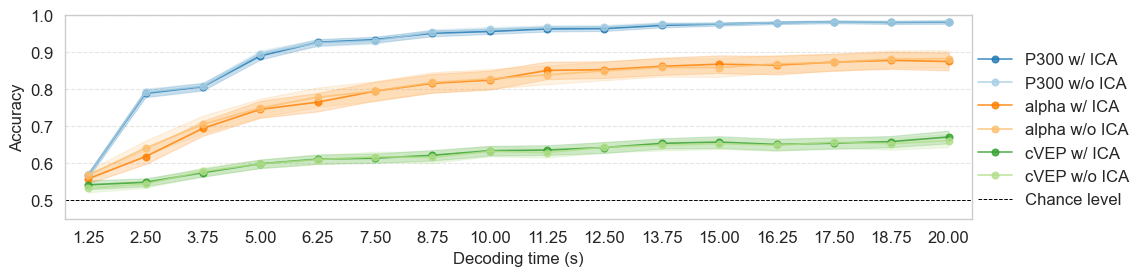

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
})
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")
#plt.rc(group='text', usetex=True)
#plt.rc(group='font', family='serif')


isi = 0.250  # seconds per bin
x = np.array(epoch_bins) * isi

# Define Paired palette
full   = sns.color_palette("Paired", 12)
blue   = full[0:2][::-1]
orange = full[6:8][::-1]
green  = full[2:4][::-1]

palette = blue + orange + green

# Inst figure
fig, ax = plt.subplots(figsize=(11.69, 3))

# Plot each of the 6 pipelines with its paired‐shade color
for (label, ds), color in zip(data.items(), palette):
    ax.plot(x, ds['mean'],
            marker=ds.get('marker', 'o'),
            linestyle=ds.get('linestyle', '-'),
            color=color,
            alpha = 0.8,
            label=label)
    ax.fill_between(x,
                    ds['mean'] - ds['se'],
                    ds['mean'] + ds['se'],
                    color=color,
                    alpha=0.2)

# Rest
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, label='Chance level')
ax.set_xlabel("Decoding time (s)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(0.45, 1.0)
ax.set_yticks([0.5,0.6,0.7,0.8,0.9,1])
ax.set_xticks(x)
ax.tick_params(labelsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
                                        # anchor legend’s upper right corner…
          bbox_to_anchor=(1.0, 0.85),    # …to the axes’ top right corner
          borderaxespad=0,             # no extra padding between legend and axes
          ncol=1,
          fontsize=12,
          frameon=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
# Remove gridline at 0.4
# for line, y in zip(ax.yaxis.get_gridlines(), ax.get_yticks()):
#     if np.isclose(y, 0.4):
#         line.set_visible(False)
plt.tight_layout()

# Save
file_name = os.path.join(fig_dir, 'decoding_arena.pdf')
plt.savefig(file_name, format="pdf", dpi=300, bbox_inches="tight")
plt.show()


## Extract Data for comparison tables

In [ ]:
import pandas as pd
time_s = np.array([2.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0])
thresholds=(0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95)

    
full_n = len(next(iter(data.values()))['mean'])
n = len(time_s)

# Determine subsample indices if needed
if full_n == n:
    idxs = np.arange(n)
elif full_n % n == 0:
    step = full_n // n
    # align by picking the last bin in each group of size 'step'
    idxs = (step - 1) + np.arange(n) * step
else:
    raise ValueError(f"Cannot align data of length {full_n} to {n} time points")

# Build accuracy-by-time table
acc_df = pd.DataFrame(
    {pipeline: infos['mean'][idxs] * 100 for pipeline, infos in data.items()},
    index=time_s
).astype(float).round(1)
acc_df.index.name = 'Time'
acc_df.to_latex(float_format="%.1f")

# Compute time-to-threshold for each pipeline
records = []
for pipeline, infos in data.items():
    subsamp = infos['mean'][idxs]
    for thr in thresholds:
        # find first subsample crossing threshold
        crossings = np.where(subsamp >= thr)[0]
        t = time_s[crossings[0]] if crossings.size else '/'
        records.append({'Strategy': pipeline, 'Accuracy': thr * 100, 'Time': t})

time_df = (
    pd.DataFrame(records)
        .pivot(index='Accuracy', columns='Strategy', values='Time')
        .round(1)
)


In [ ]:
new_order = [
    'cVEP w/ ICA', 'cVEP w/o ICA',
    'Alpha w/ ICA', 'Alpha w/o ICA',
    'P300 w/ ICA', 'P300 w/o ICA'
]

acc_df = acc_df[new_order]
time_df = time_df[new_order]

KeyError: "['Alpha w/ ICA', 'Alpha w/o ICA'] not in index"

In [ ]:
import os
from os.path import join

out_dir = join(manuscript_dir, 'tables')
os.makedirs(out_dir, exist_ok=True)

# turn the index into a column so float_format applies to it
acc_reset = acc_df.reset_index().rename(columns={'index':'Time'})
time_reset = time_df.reset_index().rename(columns={'index':'Time'})

# export
acc_tabular = acc_reset.to_latex(
    index=False,
    na_rep='',
    float_format="%.1f",
)

time_tabular = time_reset.to_latex(
    index=False,
    na_rep='',
    float_format="%.1f",
)
# Write
with open(join(out_dir, 'accuracy_threshold_table.tex'), 'w') as f:
    f.write(acc_tabular)

with open(join(out_dir, 'time_threshold_table.tex'), 'w') as f:
    f.write(time_tabular)


In [ ]:
acc_df

,cVEP w/ ICA,cVEP w/o ICA,Alpha w/ ICA,Alpha w/o ICA,P300 w/ ICA,P300 w/o ICA
Time,,,,,,
2.5,54.9,54.4,61.8,64.1,78.9,79.2
5.0,59.9,59.8,74.6,75.0,89.0,89.7
7.5,61.4,61.8,79.5,79.5,93.4,93.1
10.0,63.4,63.2,82.5,82.8,95.6,96.2
12.5,64.3,64.4,85.3,85.0,96.4,96.9
15.0,65.7,65.3,86.8,85.9,97.6,97.7
17.5,65.4,65.7,87.3,87.2,98.2,98.2
20.0,67.1,66.1,87.5,88.2,98.1,98.3


In [ ]:
acc_df

,cVEP w/ ICA,cVEP w/o ICA,Alpha w/ ICA,Alpha w/o ICA,P300 w/ ICA,P300 w/o ICA
Time,,,,,,
2.5,54.9,54.4,61.8,64.1,78.9,79.2
5.0,59.9,59.8,74.6,75.0,89.0,89.7
7.5,61.4,61.8,79.5,79.5,93.4,93.1
10.0,63.4,63.2,82.5,82.8,95.6,96.2
12.5,64.3,64.4,85.3,85.0,96.4,96.9
15.0,65.7,65.3,86.8,85.9,97.6,97.7
17.5,65.4,65.7,87.3,87.2,98.2,98.2
20.0,67.1,66.1,87.5,88.2,98.1,98.3


In [ ]:
import numpy
import mne
import sklearn
import pingouin as pg
import pyntbci as jordy
print("NumPy     :", numpy.__version__)
print("MNE       :", mne.__version__)
print("scikit-learn:", sklearn.__version__)
print("Pingouin  :", pg.__version__)
print("PyntBCI  :", jordy.__version__)

NumPy     : 1.26.4
MNE       : 1.9.0
scikit-learn: 1.4.2
Pingouin  : 0.5.5
PyntBCI  : 1.8.2
